<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Demographic
    </div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


| Student Name | Student ID | Email |
| :--- | :--- | :--- |
| **Mehmet Karaca** | 20250344 | 20250344@novaims.unl.pt |
| **Duarte Gomes** | 20250017 | 20250017@novaims.unl.pt |
| **Esra Salhi** | 20250537 | 20250537@novaims.unl.pt |

## Table of Contents



Add some contents here



# 1 Introduction <a id="introduction"></a>


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [29]:
# Imports
import os
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as Line2D
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
from cycler import cycler
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.base import clone
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from minisom import MiniSom

from sklearn.metrics import silhouette_score, davies_bouldin_score


In [30]:
import warnings

# Suppress FutureWarnings (covers the pandas 3.0 CoW warnings)
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [31]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_CustomerDB_Cleaned_Featured.csv', 'DM_AIAI_FlightsDB_Cleaned_Featured.csv']


In [32]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 46)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [33]:
customers.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'City', 'Latitude', 'Longitude', 'Postal code', 'Income',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'IsActive', 'CustomerTenureDays', 'total_flights',
       'total_flights_with_companions', 'total_distance',
       'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star', 'EnrollmentType_Standard',
       'Gender_male', 'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Marital Status_Married', 'Marital Status_Single',
       'Province or State_British Columbia', 'Province or State_Manitoba',
       'Province or State_New Brunswick', 'Province or State_Newfoundland',
       'Province or State_Nova Scotia', 'Province or State_Ontario',
     

In [34]:
customers.describe(include='number')

,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,...,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban
count,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,...,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,0.499368,0.236211,0.524848,0.377287,0.074718,0.874931,0.447696,0.469802,0.286013,0.406807,...,0.037924,0.015084,0.032122,0.322870,0.004031,0.196153,0.023878,0.006473,0.339053,0.326168
std,0.287477,0.186450,0.270156,0.303479,0.084015,0.330807,0.300579,0.200368,0.186693,0.227656,...,0.191018,0.121891,0.176330,0.467588,0.063360,0.397098,0.152673,0.080198,0.473402,0.468824
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.251407,0.070265,0.179966,0.000000,0.025561,1.000000,0.155718,0.355752,0.134454,0.215520,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500480,0.174946,0.676108,0.341215,0.047687,1.000000,0.418491,0.507375,0.294118,0.467997,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.745929,0.355081,0.734242,0.623869,0.086445,1.000000,0.711273,0.627729,0.420168,0.580960,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 2. Preparation of Data for Clustering

In this Section we prepare our data for demographic Clustering.
We have to decide, which features we will use for Clustering from Demographic Perspective.
We selected the features based on domain knowledge and our understanding of the business.
We will use the following features for Clustering from Demographic Perspective:



In [35]:
# Demographic features selection

demographic_features = [
    'Province or State_Newfoundland',
    'Province or State_Nova Scotia',
    'Province or State_Ontario',
    'Province or State_Prince Edward Island',
    'Province or State_Quebec',
    'Province or State_Saskatchewan',
    'Province or State_Yukon',
    'Location Code_Suburban',
    'Location Code_Urban',
    'Latitude',
    'Longitude',
    'Gender_male',
    'Education_College',
    'Education_High School or Below',
    'Education_Master',
    'Education_Doctor',
    'Income',
    'Marital Status_Married',
    'Marital Status_Single',
]

In [ ]:
# Show the selected featurescustomers[preference_features].head()
customers[demographic_features].head()

# Print number of metric features   
print ("Number of metric features:", len(demographic_features))

# check if metric or not 

for feature in demographic_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")

# Create the pandas dataframe df_demographic
df_demographic = pd.DataFrame(customers[demographic_features])

df_demographic.head()

Number of metric features: 19
Province or State_Newfoundland: Metric
Province or State_Nova Scotia: Metric
Province or State_Ontario: Metric
Province or State_Prince Edward Island: Metric
Province or State_Quebec: Metric
Province or State_Saskatchewan: Metric
Province or State_Yukon: Metric
Location Code_Suburban: Metric
Location Code_Urban: Metric
Latitude: Metric
Longitude: Metric
Gender_male: Metric
Education_College: Metric
Education_High School or Below: Metric
Education_Master: Metric
Education_Doctor: Metric
Income: Metric
Marital Status_Married: Metric
Marital Status_Single: Metric


,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,Latitude,Longitude,Gender_male,Education_College,Education_High School or Below,Education_Master,Education_Doctor,Income,Marital Status_Married,Marital Status_Single
0,0,0,1,0,0,0,0,0,1,0.037680,0.676108,0,0,0,0,0,0.701593,1,0
1,0,0,0,0,0,0,0,0,0,0.595360,0.261899,1,1,0,0,0,0.000000,0,0
2,0,0,0,0,0,0,0,0,1,0.355081,0.144954,1,1,0,0,0,0.000000,0,1
3,0,0,1,0,0,0,0,1,0,0.037680,0.676108,1,1,0,0,0,0.000000,0,1
4,0,0,0,0,1,0,0,1,0,0.137786,0.720675,1,0,0,0,0,0.978506,1,0


Before starting with the first Clustering Method, we will remove highly correlated features from the dataset. Highly correlated features can negatively impact the performance of clustering algorithms (e.g., KMeans). We will use a correlation threshold of 0.8 to identify and remove highly correlated features.

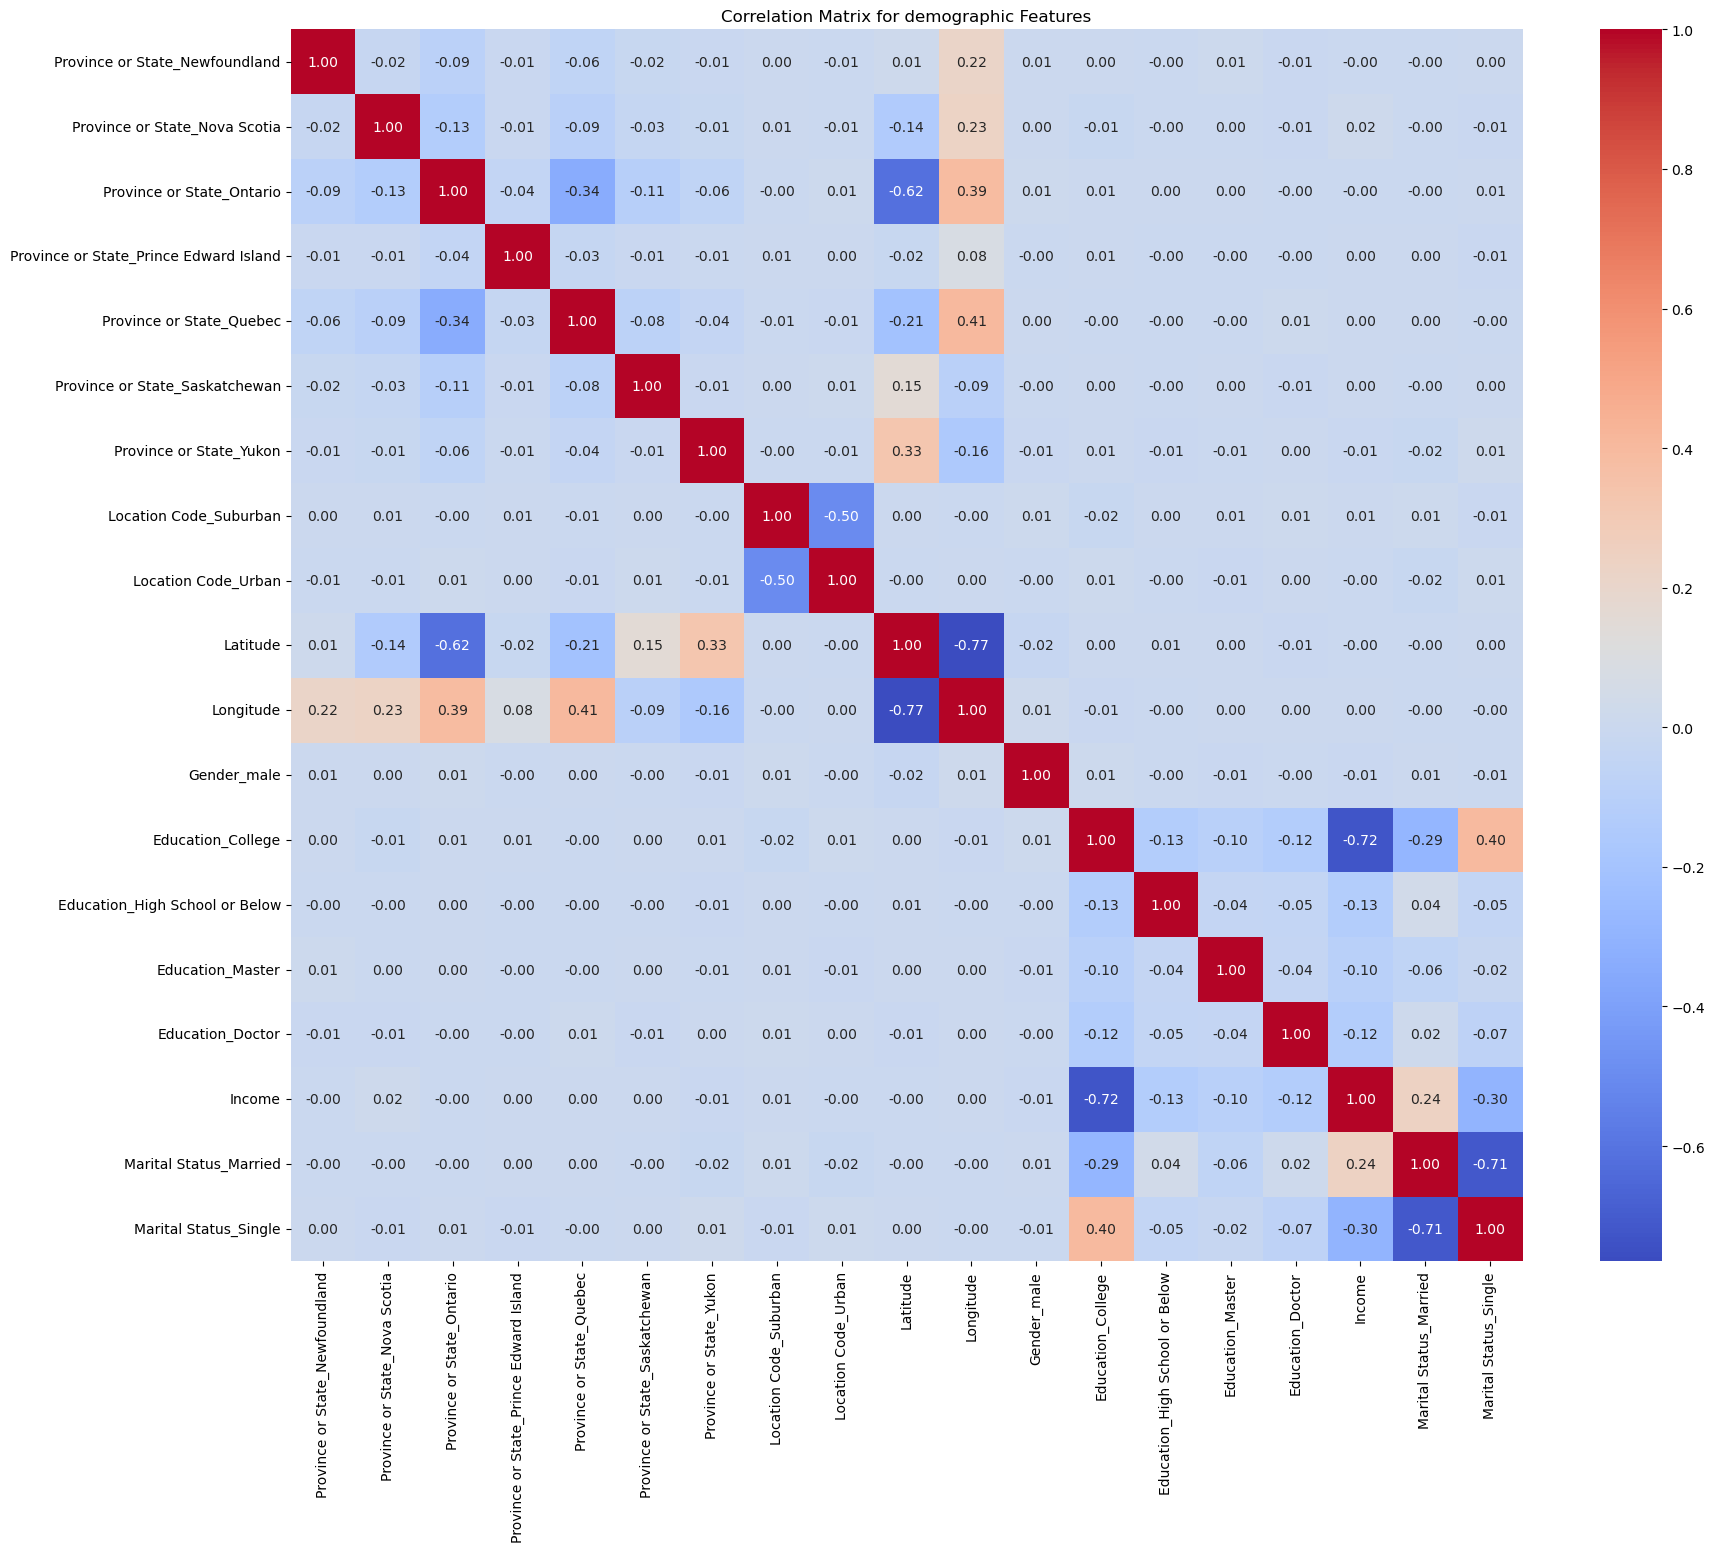

Pairs with correlation > 0.8 or < -0.8:
Series([], dtype: float64)


In [52]:
# Check for correlation inside the demographic features
plt.figure(figsize=(20, 16))
correlation_matrix = df_demographic.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for demographic Features")
plt.show()

threshold = 0.8
unstacked = correlation_matrix.unstack()
high_corr = unstacked[(unstacked.abs() > threshold) & (unstacked != 1.0)].drop_duplicates()

print(f"Pairs with correlation > {threshold} or < -{threshold}:")
print(high_corr)

We did not identify any highly correlated features, so all variables will be considered.

# 3.Demographic Clustering 

Clustering Methods:

Methods to use

- KMeans++ Clustering
- Density Clustering
    - Mean Shift
    - DBSCAN
- Probability-based Models
    - Gaussian Mixture Models
- Self Organizing Maps

## 3.1 KMeans++ Clustering

First we start with KMeans++ Clustering Method and use it as our baseline to compare with other Clustering Methods.

Running K-Means optimization for K=2 to 20...

Top 3 Configurations by Silhouette:


,K,Inertia,R2_Score,Silhouette,Inertia_Pct_Change,R2_Pct_Change,Sil_Pct_Change
18,20,12994.217400,0.621055,0.244575,-1.903716,1.198311,2.497442
17,19,13246.391105,0.613701,0.238615,-1.909820,1.240765,2.614906
16,18,13504.298853,0.606180,0.232535,-4.051899,2.820986,8.041324


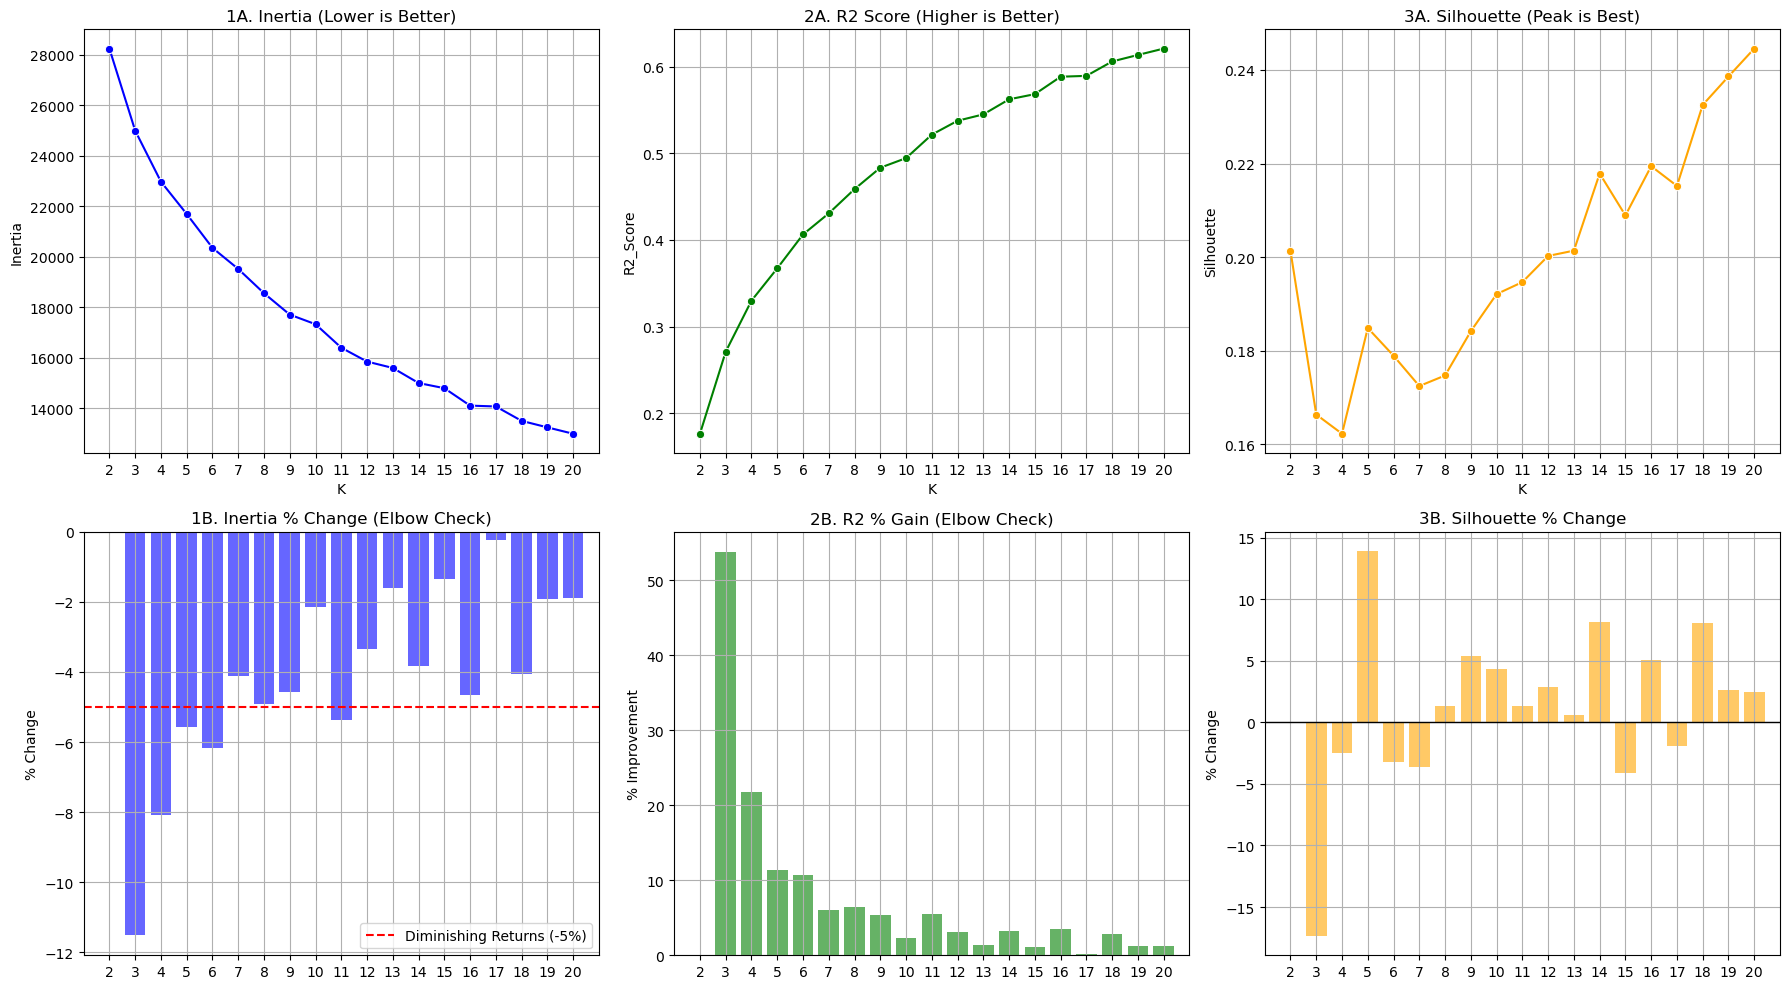

In [54]:
# --- K-Means Optimization with Gradients ---

def optimize_kmeans_gradient(data, k_range=range(2, 21)):
    """
    Runs KMeans++ and calculates Inertia, R2, and Silhouette,
    PLUS their percentage changes (gradients) to find the Elbow.
    """
    X = data.values if isinstance(data, pd.DataFrame) else data
    
    # Calculate Total Sum of Squares (SST) - Once
    centroid = X.mean(axis=0)
    sst = np.sum((X - centroid) ** 2)
    
    results = []
    
    print(f"Running K-Means optimization for K={k_range.start} to {k_range.stop - 1}...")
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        kmeans.fit(X)
        
        ssw = kmeans.inertia_
        r2 = 1 - (ssw / sst)
        sil = silhouette_score(X, kmeans.labels_)
        
        results.append({
            'K': k,
            'Inertia': ssw,
            'R2_Score': r2,
            'Silhouette': sil
        })
        
    df = pd.DataFrame(results)
    
    # Calculate Gradients (Percentage Change)
    df['Inertia_Pct_Change'] = df['Inertia'].pct_change() * 100
    df['R2_Pct_Change'] = df['R2_Score'].pct_change() * 100
    df['Sil_Pct_Change'] = df['Silhouette'].pct_change() * 100
    
    return df

# --- EXECUTION ---
results_df = optimize_kmeans_gradient(df_demographic, k_range=range(2, 21))

# Display Top Results (Sorted by Silhouette)
print("\nTop 3 Configurations by Silhouette:")
display(results_df.sort_values('Silhouette', ascending=False).head(3))

# --- VISUALIZATION (2x3 Grid) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Define common X limits so top and bottom align perfectly
x_min, x_max = results_df['K'].min() - 1, results_df['K'].max() + 1

# ---------------------------------------------------------
# COLUMN 1: INERTIA
# ---------------------------------------------------------
# Top: Absolute (Line)
sns.lineplot(data=results_df, x='K', y='Inertia', marker='o', ax=axes[0,0], color='blue')
axes[0,0].set_title('1A. Inertia (Lower is Better)')
axes[0,0].grid(True)
axes[0,0].set_xticks(results_df['K'])
axes[0,0].set_xlim(x_min, x_max)

# Bottom: Gradient (Bar)
axes[1,0].bar(results_df['K'], results_df['Inertia_Pct_Change'], color='blue', alpha=0.6)
axes[1,0].set_title('1B. Inertia % Change (Elbow Check)')
axes[1,0].set_ylabel('% Change')
axes[1,0].axhline(-5, color='red', linestyle='--', label='Diminishing Returns (-5%)')
axes[1,0].grid(True)
axes[1,0].legend()
axes[1,0].set_xticks(results_df['K'])
axes[1,0].set_xlim(x_min, x_max)


# ---------------------------------------------------------
# COLUMN 2: R2 SCORE
# ---------------------------------------------------------
# Top: Absolute (Line)
sns.lineplot(data=results_df, x='K', y='R2_Score', marker='o', ax=axes[0,1], color='green')
axes[0,1].set_title('2A. R2 Score (Higher is Better)')
axes[0,1].grid(True)
axes[0,1].set_xticks(results_df['K'])
axes[0,1].set_xlim(x_min, x_max)

# Bottom: Gradient (Bar)
axes[1,1].bar(results_df['K'], results_df['R2_Pct_Change'], color='green', alpha=0.6)
axes[1,1].set_title('2B. R2 % Gain (Elbow Check)')
axes[1,1].set_ylabel('% Improvement')
axes[1,1].grid(True)
axes[1,1].set_xticks(results_df['K'])
axes[1,1].set_xlim(x_min, x_max)


# ---------------------------------------------------------
# COLUMN 3: SILHOUETTE
# ---------------------------------------------------------
# Top: Absolute (Line)
sns.lineplot(data=results_df, x='K', y='Silhouette', marker='o', ax=axes[0,2], color='orange')
axes[0,2].set_title('3A. Silhouette (Peak is Best)')
axes[0,2].grid(True)
axes[0,2].set_xticks(results_df['K'])
axes[0,2].set_xlim(x_min, x_max)

# Bottom: Gradient (Bar)
axes[1,2].bar(results_df['K'], results_df['Sil_Pct_Change'], color='orange', alpha=0.6)
axes[1,2].set_title('3B. Silhouette % Change')
axes[1,2].set_ylabel('% Change')
axes[1,2].axhline(0, color='black', linewidth=1)
axes[1,2].grid(True)
axes[1,2].set_xticks(results_df['K'])
axes[1,2].set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

Explanation for the chosen K

- K = 5 was selected based on the analysis of inertia and explained variance, which show clear diminishing returns beyond this point.
Up to five clusters capture the main demographic structure of the data, while additional clusters mainly increase complexity without substantial explanatory gains.
Although silhouette scores improve for higher K, this reflects over-segmentation rather than meaningful demographic differentiation.

In [55]:
# --- Manual Selection & Saving (K-Means) ---

# 1. INPUT CHOSEN K HERE
selected_k = 5

print(f"Finalizing K-Means++ with K={selected_k}...")

# 2. Fit the Final Model
X_final = df_demographic.values 

kmeans_final = KMeans(n_clusters=selected_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_final)

# 3. Create a Dataframe for evaluation and save it there
df_demographic_evaluation = df_demographic.copy()
df_demographic_evaluation['cluster_kmeans'] = kmeans_labels

# 4. Final Confirmation & Stats
sil_score = silhouette_score(X_final, kmeans_labels)
print(f"Done. 'cluster_kmeans' column added.")
print(f"Final Inertia: {kmeans_final.inertia_:.2f}")
print(f"Final Silhouette Score: {sil_score:.4f}")

# Show distribution
print("\nCluster Distribution:")
print(df_demographic_evaluation['cluster_kmeans'].value_counts().sort_index())

Finalizing K-Means++ with K=5...
Done. 'cluster_kmeans' column added.
Final Inertia: 21698.92
Final Silhouette Score: 0.1849

Cluster Distribution:
cluster_kmeans
0    3747
1    4602
2    3019
3    2737
4    2270
Name: count, dtype: int64


Number of Clusters:
The number of clusters was fixed at K = 5, as it provides a good balance between segmentation detail and interpretability. The resulting clusters are well distributed in size, avoiding both over-segmentation and dominant clusters, which supports actionability and demographic interpretability.

Cluster Distribution:
The final solution produces balanced clusters (ranging from approximately 2,200 to 4,600 observations), indicating a stable and meaningful segmentation without excessively small or noisy groups.

Inertia (Within-Cluster Dispersion):
The final inertia value (21,698.92) reflects a substantial reduction compared to lower values of K. The inertia curve shows clear diminishing returns beyond K = 5, indicating that additional clusters would only marginally improve compactness while increasing complexity.

Silhouette Score:
The silhouette score of 0.1849 indicates moderate cluster separation, which is expected for demographic data characterized by natural overlap between profiles. While higher silhouette values can be achieved with larger K, this would lead to over-segmentation and reduced interpretability.

Explained Variance (R² Score):
At K = 5, the clustering solution explains a meaningful proportion of the total variance in the demographic features. Further increases in K lead to only marginal gains in explained variance, confirming that the main structure of the data is already captured.

Interpretability and Stability:
The K = 5 solution yields clearly interpretable demographic profiles and shows stable behavior when compared with alternative clustering approaches. This stability reinforces the suitability of K-Means as the final method for demographic segmentation.

Final Decision:
Based on inertia reduction, explained variance, silhouette behavior, cluster balance, and interpretability, K-Means with K = 5 was selected.

## 3.2 Density based & Probabilistic Clustering

### 3.2.1 Mean Shift Clustering

Analyzing Mean Shift for quantiles: [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.1, 0.12, 0.15]...

Mean Shift Analysis Results:


,Quantile,Bandwidth,n_clusters,Min_Cluster_Size,Valid_Solution,Silhouette,Davies-Bouldin,R2 Score,Silhouette_plot,Davies-Bouldin_plot,R2 Score_plot,Clusters_Delta,Sil_Delta,DB_Delta,R2_Delta
0,0.01,0.716134,477,1,False,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN,NaN
1,0.02,0.963124,529,1,False,NaN,NaN,NaN,0.000,0.000,0.000,52.0,0.000,0.000,0.000
2,0.03,1.125994,40,1,False,NaN,NaN,NaN,0.000,0.000,0.000,-489.0,0.000,0.000,0.000
3,0.04,1.204470,8,123,True,0.120,2.051,0.311,0.120,2.051,0.311,-32.0,0.120,2.051,0.311
4,0.05,1.260714,3,3002,True,0.155,2.277,0.228,0.155,2.277,0.228,-5.0,0.035,0.226,-0.083
5,0.06,1.314771,2,4754,True,0.201,1.942,0.176,0.201,1.942,0.176,-1.0,0.046,-0.335,-0.052
6,0.08,1.381864,2,4754,True,0.201,1.942,0.176,0.201,1.942,0.176,0.0,0.000,0.000,0.000
7,0.10,1.452875,2,4754,True,0.201,1.942,0.176,0.201,1.942,0.176,0.0,0.000,0.000,0.000
8,0.12,1.507168,1,16375,False,NaN,NaN,NaN,0.000,0.000,0.000,-1.0,-0.201,-1.942,-0.176
9,0.15,1.587707,1,16375,False,NaN,NaN,NaN,0.000,0.000,0.000,0.0,0.000,0.000,0.000


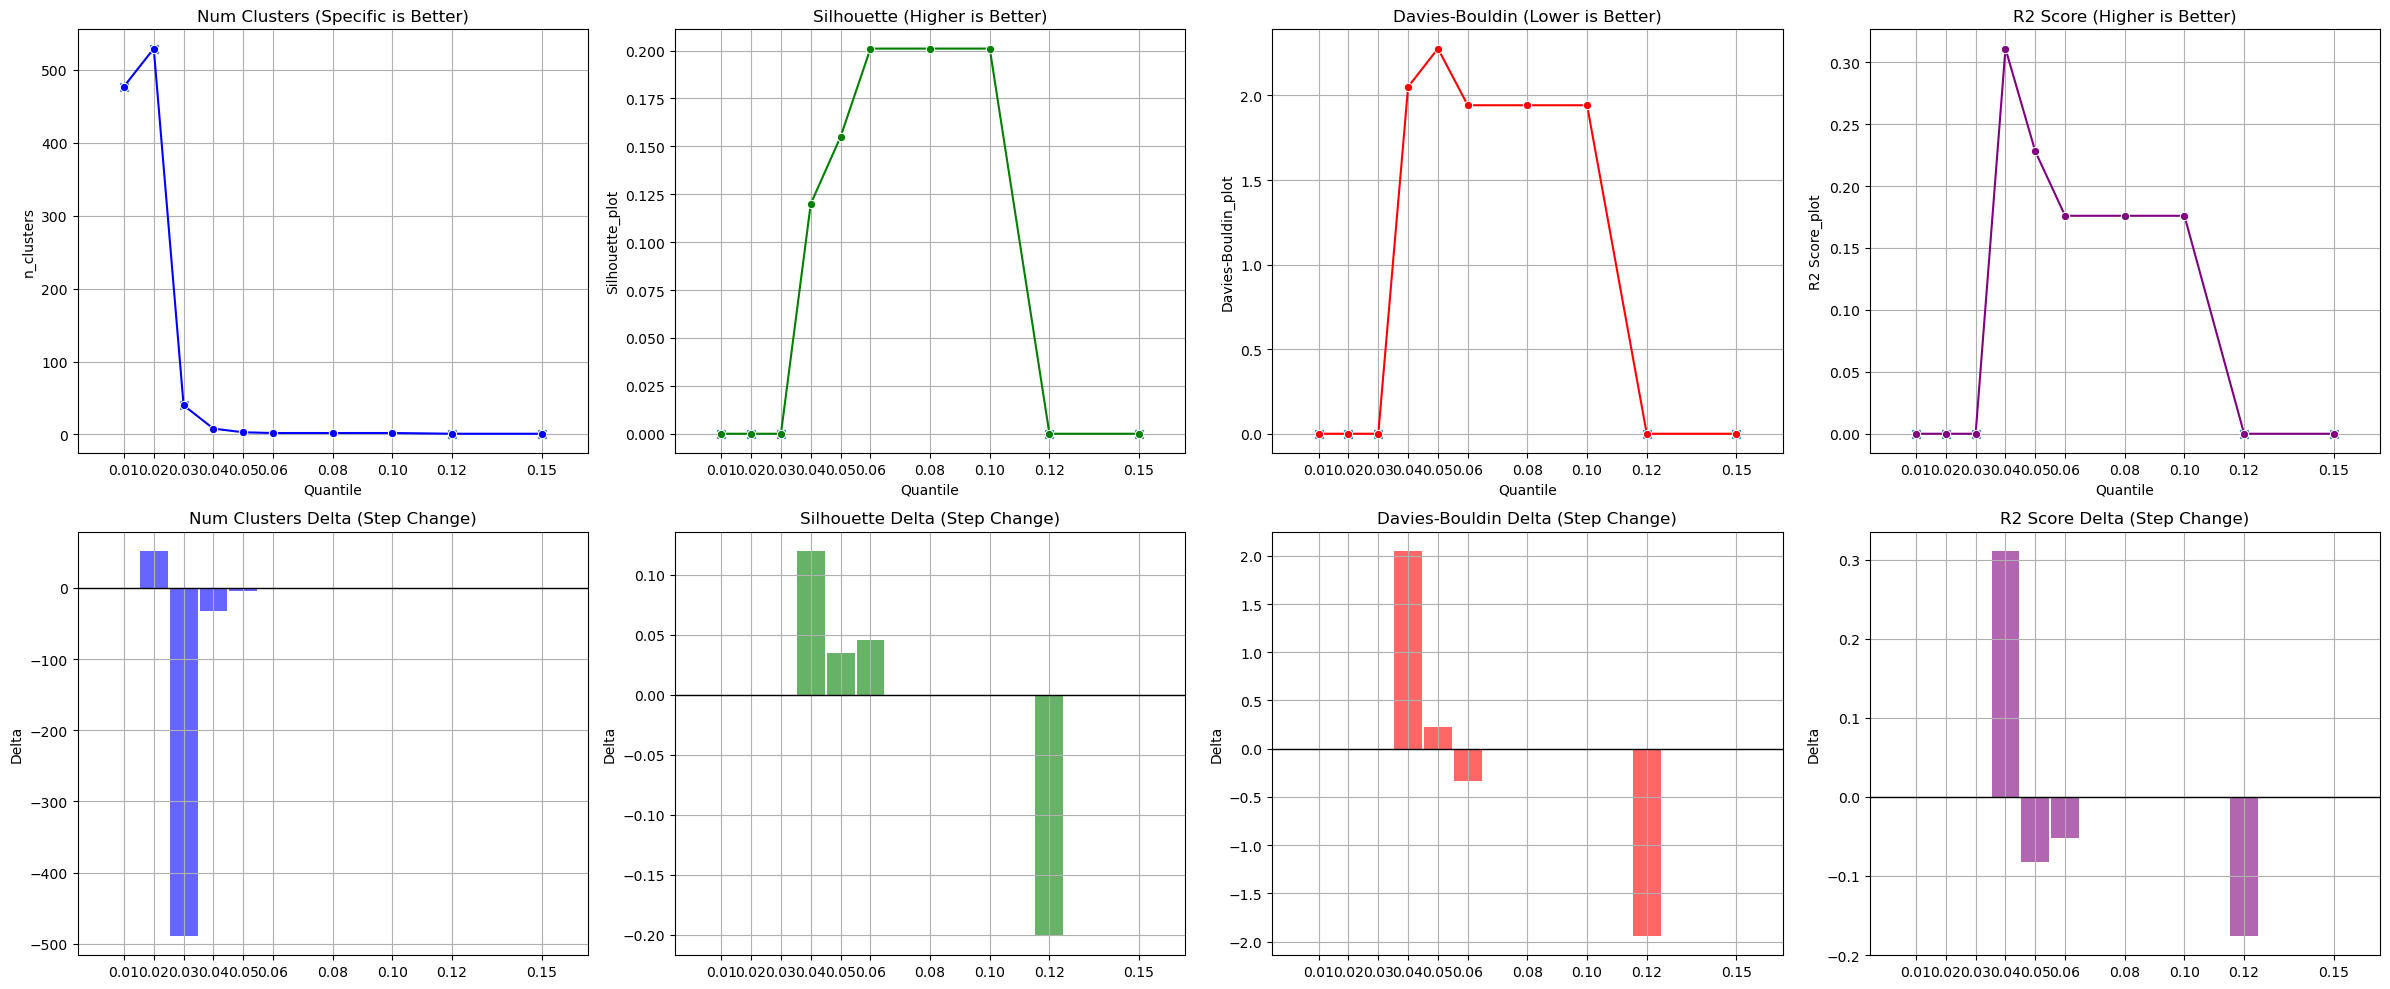

In [ ]:
# --- Optimization & Visualization ---

def analyze_meanshift_quantiles(data, quantile_range=[0.1, 0.15, 0.2, 0.25, 0.3], min_cluster_size=20):
    """
    Test different quantiles for Mean Shift and plot the trade-offs.
    """
    X = data.values if isinstance(data, pd.DataFrame) else data

    # Calculate Global Centroid for R2
    centroid_global = X.mean(axis=0)
    sst = np.sum((X - centroid_global) ** 2)

    results_ms = []

    print(f"Analyzing Mean Shift for quantiles: {quantile_range}...")

    for q in quantile_range:
        try:
            # 1. Estimate Bandwidth
            bandwidth = estimate_bandwidth(X, quantile=q, n_samples=min(2000, len(X)))
            if bandwidth is None or bandwidth <= 0:
                continue

            # 2. Run Mean Shift
            ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
            ms.fit(X)

            labels = ms.labels_
            unique_labels = np.unique(labels)
            n_clusters = len(unique_labels)

            counts = np.bincount(labels)
            min_size = int(counts.min())

            # 3. Calculate Metrics
            valid_solution = (n_clusters > 1 and min_size >= min_cluster_size and n_clusters < len(X))

            if valid_solution:
                sil = float(silhouette_score(X, labels))
                db_score = float(davies_bouldin_score(X, labels))

                # R2 Score Calculation
                ssw = 0.0
                for k in unique_labels:
                    cluster_data = X[labels == k]
                    ssw += np.sum((cluster_data - cluster_data.mean(axis=0)) ** 2)
                r2 = float(1 - (ssw / sst))
            else:
                sil, db_score, r2 = np.nan, np.nan, np.nan

            results_ms.append({
                'Quantile': q,
                'Bandwidth': round(float(bandwidth), 6),
                'n_clusters': int(n_clusters),
                'Min_Cluster_Size': int(min_size),
                'Valid_Solution': bool(valid_solution),
                'Silhouette': np.nan if np.isnan(sil) else round(sil, 3),
                'Davies-Bouldin': np.nan if np.isnan(db_score) else round(db_score, 3),
                'R2 Score': np.nan if np.isnan(r2) else round(r2, 3)
            })

        except Exception as e:
            print(f"Skipping quantile {q}: {e}")

    df_out = pd.DataFrame(results_ms)
    if not df_out.empty:
        df_out = df_out.sort_values('Quantile').reset_index(drop=True)

        # Create plot-friendly columns
        df_out['Silhouette_plot'] = df_out['Silhouette'].fillna(0)
        df_out['Davies-Bouldin_plot'] = df_out['Davies-Bouldin'].fillna(0)
        df_out['R2 Score_plot'] = df_out['R2 Score'].fillna(0)

        # Deltas
        df_out['Clusters_Delta'] = df_out['n_clusters'].diff()
        df_out['Sil_Delta'] = df_out['Silhouette_plot'].diff()
        df_out['DB_Delta'] = df_out['Davies-Bouldin_plot'].diff()
        df_out['R2_Delta'] = df_out['R2 Score_plot'].diff()

    return df_out


# --- EXECUTE ANALYSIS ---
ms_metrics_df = analyze_meanshift_quantiles(
    df_demographic,
    quantile_range=[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10, 0.12, 0.15],
    min_cluster_size=20
)

print("\nMean Shift Analysis Results:")
display(ms_metrics_df)

# --- VISUALIZATION (2x4 Grid) ---
if not ms_metrics_df.empty:
    fig, axes = plt.subplots(2, 4, figsize=(24, 10))

    # bar width
    step_size = ms_metrics_df['Quantile'].diff().mean() if len(ms_metrics_df) > 1 else 0.02
    bar_width = float(step_size) * 0.6

    x_min = float(ms_metrics_df['Quantile'].min() - step_size)
    x_max = float(ms_metrics_df['Quantile'].max() + step_size)

    def plot_ms_pair(col_idx, metric_col, change_col, title_base, color, better='Higher'):
        # Top
        sns.lineplot(data=ms_metrics_df, x='Quantile', y=metric_col, marker='o', ax=axes[0, col_idx], color=color)

        # Highlight invalid solutions
        invalid = ms_metrics_df[~ms_metrics_df['Valid_Solution']]
        axes[0, col_idx].scatter(invalid['Quantile'], invalid[metric_col], marker='x')

        axes[0, col_idx].set_title(f'{title_base} ({better} is Better)')
        axes[0, col_idx].grid(True)
        axes[0, col_idx].set_xticks(ms_metrics_df['Quantile'])
        axes[0, col_idx].set_xlim(x_min, x_max)

        # Bottom
        axes[1, col_idx].bar(ms_metrics_df['Quantile'], ms_metrics_df[change_col], color=color, alpha=0.6, width=bar_width)
        axes[1, col_idx].set_title(f'{title_base} Delta (Step Change)')
        axes[1, col_idx].set_ylabel('Delta')
        axes[1, col_idx].axhline(0, color='black', linewidth=1)
        axes[1, col_idx].grid(True)
        axes[1, col_idx].set_xticks(ms_metrics_df['Quantile'])
        axes[1, col_idx].set_xlim(x_min, x_max)

    plot_ms_pair(0, 'n_clusters', 'Clusters_Delta', 'Num Clusters', 'blue', better='Specific')
    plot_ms_pair(1, 'Silhouette_plot', 'Sil_Delta', 'Silhouette', 'green', better='Higher')
    plot_ms_pair(2, 'Davies-Bouldin_plot', 'DB_Delta', 'Davies-Bouldin', 'red', better='Lower')
    plot_ms_pair(3, 'R2 Score_plot', 'R2_Delta', 'R2 Score', 'purple', better='Higher')

    plt.tight_layout()
    plt.show()
else:
    print("Mean Shift returned no results for the provided quantiles.")


Number of Clusters:
The selected quantile should produce a reasonable number of clusters, preferably below 20, to ensure interpretability and actionability of the resulting segments. Very small quantiles resulted in excessive over-segmentation, while larger quantiles caused the clustering to collapse into a single cluster.

Silhouette Score:
The silhouette score was used to assess cluster cohesion and separation. Higher values were preferred; however, acceptable silhouette scores were often associated with a large number of small clusters, reducing practical interpretability.

Davies–Bouldin Score:
The Davies–Bouldin score was evaluated to measure cluster compactness and separation. Lower values indicate better clustering quality, but similarly to the silhouette score, improvements were mainly observed in highly fragmented solutions.

R² Score:
The R² score was used to evaluate the proportion of variance explained by the clustering solution. Higher values were favored; however, higher R² scores were achieved at the cost of increased fragmentation and reduced interpretability.

Stability and Interpretability:
Beyond metric optimization, the stability of the clustering solution and the interpretability of the resulting demographic profiles were considered. Even within quantile ranges that performed well on internal metrics, the resulting clusters were not stable or easily interpretable.

Final Decision:
Although certain quantiles achieved reasonable internal validation scores, Mean Shift did not produce a balanced solution that satisfied both clustering quality and interpretability requirements. 
The density-based analysis shows that the demographic data does not exhibit stable density modes. Mean Shift either produces extreme over-segmentation with many small clusters or collapses into very few large clusters, depending on the bandwidth. Although a narrow range of quantiles yields technically valid solutions, these do not provide a meaningful or interpretable demographic segmentation.

In [70]:
# --- Manual Selection & Saving ---

# 1. INPUT YOUR CHOSEN QUANTILE HERE
selected_quantile = 0.04  # <--- Based on our analysis: valid + <20 clusters (8 clusters)

print(f"Finalizing Mean Shift with Quantile: {selected_quantile}...")

# 2. Re-fit the specific model
X_final = df_demographic.values
final_bandwidth = estimate_bandwidth(
    X_final,
    quantile=selected_quantile,
    n_samples=min(2000, len(X_final)) 
)

ms_final = MeanShift(bandwidth=final_bandwidth, bin_seeding=True)
ms_labels = ms_final.fit_predict(X_final)

# 3. Basic validation checks
n_clusters_final = len(np.unique(ms_labels))
min_cluster_size = np.bincount(ms_labels).min()

print(f"Bandwidth used: {final_bandwidth:.6f}")
print(f"Clusters found: {n_clusters_final}")
print(f"Min cluster size: {min_cluster_size}")

# Enforce the same interpretability rules used in analysis
if n_clusters_final < 2 or n_clusters_final > 20 or min_cluster_size < 20:
    print("WARNING: Mean Shift result is not suitable (too few/many clusters or very small clusters).")

# 4. Save to DataFrame
df_demographic_evaluation['cluster_meanshift'] = ms_labels

# 5. Final Confirmation
print(f"Done. 'cluster_meanshift' column added with {n_clusters_final} clusters.")


Finalizing Mean Shift with Quantile: 0.04...
Bandwidth used: 1.204470
Clusters found: 8
Min cluster size: 123
Done. 'cluster_meanshift' column added with 8 clusters.


Using a quantile of 0.04, Mean Shift produced a technically valid solution with 8 clusters and a minimum cluster size of 123 observations. Although this configuration avoids both over-segmentation and cluster collapse, the resulting segmentation remains less interpretable and less stable than the K-Means solution.

### 3.2.2 DBSCAN Clustering

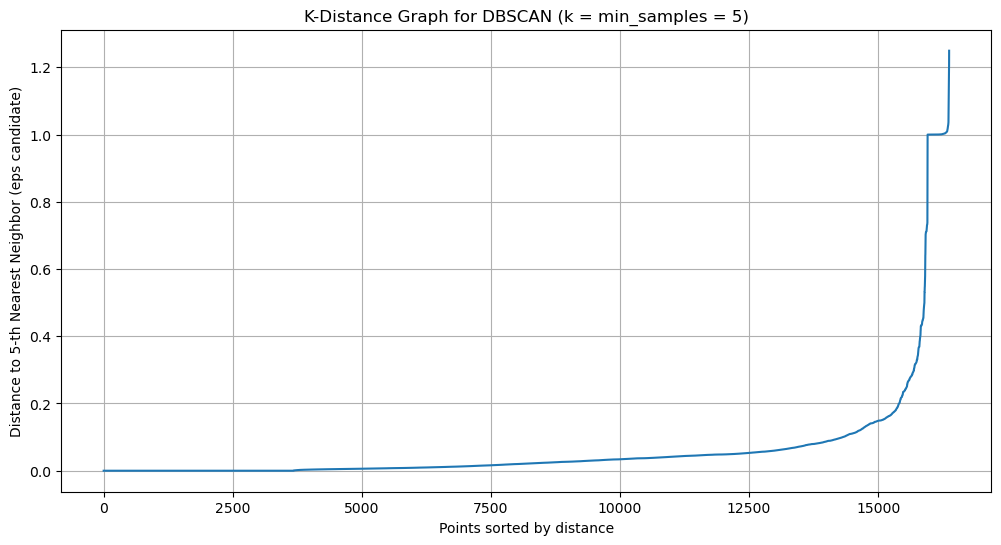

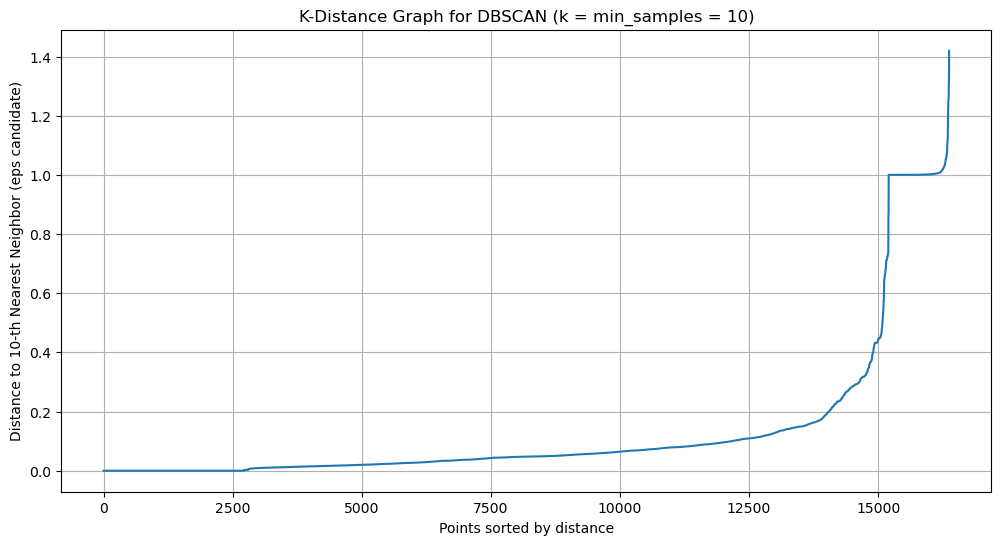

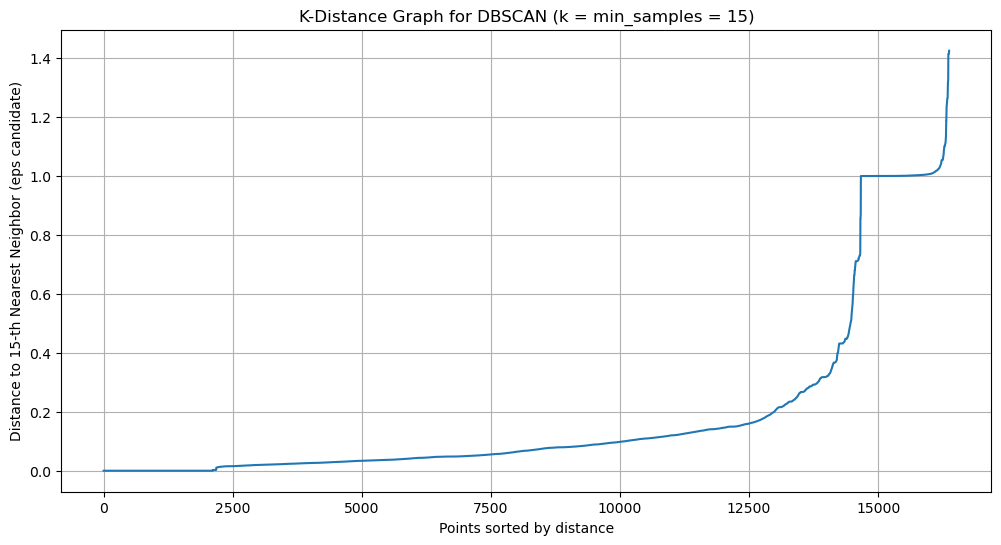

In [71]:
# --- DBSCAN Analysis (K-Distance Graph) ---

def plot_k_distance(data, k):
    """
    Plots the k-distance graph to help find the optimal 'eps' for DBSCAN.
    The 'knee' of the curve suggests the optimal eps value.
    """
    X = data.values if hasattr(data, 'values') else data

    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)

    # Sort distance values by the k-th neighbor
    distances = np.sort(distances[:, k-1])

    plt.figure(figsize=(12, 6))
    plt.plot(distances)
    plt.title(f"K-Distance Graph for DBSCAN (k = min_samples = {k})")
    plt.ylabel(f"Distance to {k}-th Nearest Neighbor (eps candidate)")
    plt.xlabel("Points sorted by distance")
    plt.grid(True)
    plt.show()


# --- EXECUTION ---
# Try several k values (min_samples) to assess stability
for k in [5, 10, 15]:
    plot_k_distance(df_demographic, k=k)


Density-based clustering methods were evaluated using Mean Shift and DBSCAN; however, due to the diffuse density structure and high dimensionality of the demographic data, no stable and interpretable density-based segmentation could be identified.

In [72]:
# --- DBSCAN Analysis (Fixed Eps, Variable Min_Samples) ---

def analyze_dbscan_min_samples(data, fixed_eps, ms_range=[5, 10, 15, 20, 25, 30, 35, 40], min_cluster_size=20):
    """
    Tests different min_samples values for a fixed eps and reports metrics.
    """
    X = data.values if isinstance(data, pd.DataFrame) else data
    results = []

    print(f"Analyzing DBSCAN with fixed eps={fixed_eps} for min_samples: {ms_range}...")

    for ms in ms_range:
        # Run DBSCAN
        db = DBSCAN(eps=fixed_eps, min_samples=ms, n_jobs=-1)
        labels = db.fit_predict(X)

        # Basic Stats (excluding noise -1)
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

        n_noise = np.sum(labels == -1)
        noise_pct = n_noise / len(labels)

        # Clustered stats
        mask = labels != -1
        n_clustered = int(np.sum(mask))
        clustered_pct = n_clustered / len(labels)

        # Minimum cluster size
        if n_clusters > 0 and n_clustered > 0:
            cluster_sizes = [np.sum(labels == c) for c in unique_labels if c != -1]
            min_size = int(np.min(cluster_sizes))
        else:
            min_size = 0

        # Evaluatio
        valid_solution = (n_clusters > 1) and (min_size >= min_cluster_size) and (clustered_pct >= 0.5)

        if valid_solution:
            sil = float(silhouette_score(X[mask], labels[mask]))
            db_score = float(davies_bouldin_score(X[mask], labels[mask]))
        else:
            sil, db_score = np.nan, np.nan

        results.append({
            'Min_Samples': ms,
            'Clusters': int(n_clusters),
            'Noise_Pct': round(noise_pct * 100, 1),
            'Clustered_Pct': round(clustered_pct * 100, 1),
            'Min_Cluster_Size': int(min_size),
            'Valid_Solution': bool(valid_solution),
            'Silhouette': np.nan if np.isnan(sil) else round(sil, 3),
            'Davies-Bouldin': np.nan if np.isnan(db_score) else round(db_score, 3)
        })

    df_out = pd.DataFrame(results)

    # Deltas instead of % change
    if not df_out.empty:
        df_out['Noise_Delta'] = df_out['Noise_Pct'].diff()
        df_out['Clusters_Delta'] = df_out['Clusters'].diff()
        df_out['Sil_Delta'] = df_out['Silhouette'].diff()

    return df_out


# --- EXECUTE ANALYSIS ---
db_metrics_df = analyze_dbscan_min_samples(
    df_demographic,
    fixed_eps=1.0,
    ms_range=[10, 15, 20, 25, 30, 40, 50, 60, 70, 80],
    min_cluster_size=20
)

print("\nDBSCAN Analysis Results:")
display(db_metrics_df)

Analyzing DBSCAN with fixed eps=1.0 for min_samples: [10, 15, 20, 25, 30, 40, 50, 60, 70, 80]...

DBSCAN Analysis Results:


,Min_Samples,Clusters,Noise_Pct,Clustered_Pct,Min_Cluster_Size,Valid_Solution,Silhouette,Davies-Bouldin,Noise_Delta,Clusters_Delta,Sil_Delta
0,10,85,5.3,94.7,10,False,NaN,NaN,NaN,NaN,NaN
1,15,63,7.7,92.3,15,False,NaN,NaN,2.4,-22.0,NaN
2,20,44,10.7,89.3,20,True,0.073,1.136,3.0,-19.0,NaN
3,25,35,12.5,87.5,11,False,NaN,NaN,1.8,-9.0,NaN
4,30,27,14.5,85.5,30,True,0.117,1.262,2.0,-8.0,NaN
5,40,23,17.2,82.8,40,True,0.134,1.268,2.7,-4.0,0.017
6,50,13,20.2,79.8,51,True,0.187,1.551,3.0,-10.0,0.053
7,60,10,22.8,77.2,61,True,0.213,1.656,2.6,-3.0,0.026
8,70,9,23.3,76.7,544,True,0.221,1.748,0.5,-1.0,0.008
9,80,11,24.2,75.8,111,True,0.199,1.627,0.9,2.0,-0.022


DBSCAN was evaluated by fixing the epsilon parameter (ε = 1.0), based on the k-distance analysis, and varying the min_samples parameter to assess the stability and quality of the resulting clustering solutions.

For low values of min_samples, DBSCAN produced a large number of clusters with very small cluster sizes, indicating over-segmentation despite low noise levels. As min_samples increased, the number of clusters decreased and cluster sizes became more stable; however, this was accompanied by a steady increase in the percentage of noise points.

Although some configurations (e.g., min_samples between 40 and 70) achieved moderate silhouette scores, these improvements came at the cost of higher noise levels and reduced interpretability. Moreover, the resulting clusters remained highly fragmented and sensitive to parameter changes.

Overall, the analysis shows that DBSCAN does not provide a robust trade-off between cluster quality, noise control, and interpretability for the demographic dataset.

In [73]:
# --- Manual Selection & Saving ---

# 1. Input eps and min_samples
selected_eps = 1.0
selected_min_samples = 30  

print(f"Finalizing DBSCAN with eps={selected_eps}, min_samples={selected_min_samples}...")

# 2. Re-fit the specific model
db_final = DBSCAN(eps=selected_eps, min_samples=selected_min_samples, n_jobs=-1)
db_labels = db_final.fit_predict(df_demographic)

# 3. Save to DataFrame
df_demographic_evaluation['cluster_dbscan'] = db_labels

# 4. Final Confirmation
n_clusters_final = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_count = list(db_labels).count(-1)
noise_pct_final = noise_count / len(db_labels)

print(f"Done. 'cluster_dbscan' column added.")
print(f"Stats: {n_clusters_final} clusters found.")
print(f"Noise Level: {noise_pct_final:.1%} ({noise_count} noise points)")


Finalizing DBSCAN with eps=1.0, min_samples=30...
Done. 'cluster_dbscan' column added.
Stats: 27 clusters found.
Noise Level: 14.5% (2369 noise points)


Using ε = 1.0 and min_samples = 30, DBSCAN produced a technically valid clustering with 27 clusters and approximately 14.5% of the observations classified as noise. Despite this configuration representing a balanced trade-off within DBSCAN, the resulting segmentation remains highly fragmented and less interpretable when compared to partition-based methods.

### 3.2.3 Gaussian Mixture Models

Analyzing GMM (full) for components: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]...


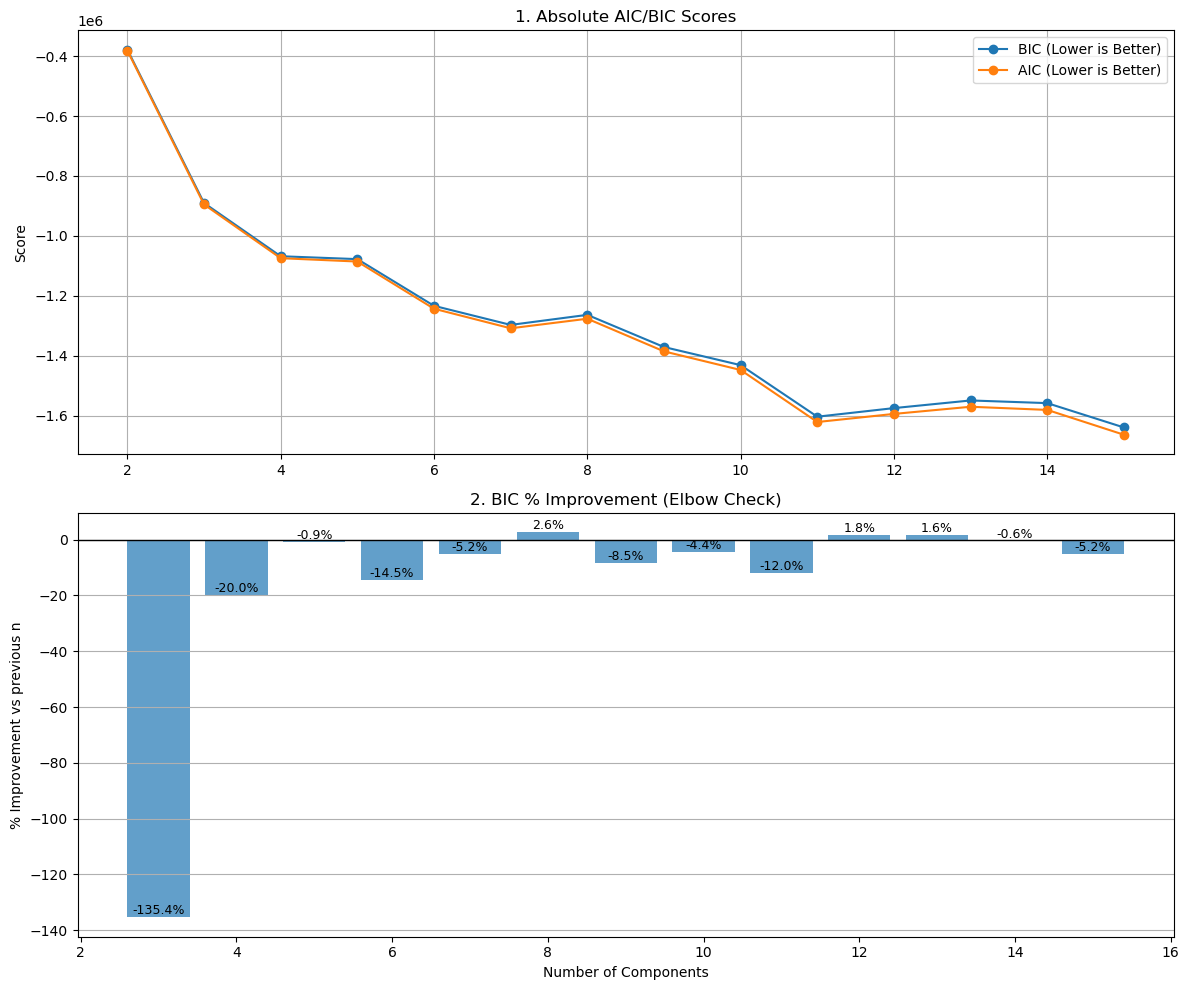

In [74]:
# --- GMM Analysis ---

def analyze_gmm_gradient(data, n_range=range(2, 16), covariance_type='full'):
    """
    Calculates AIC/BIC and their percentage improvement
    to help find the 'Elbow' point.
    """
    X = data.values if isinstance(data, pd.DataFrame) else data
    results = []

    print(f"Analyzing GMM ({covariance_type}) for components: {list(n_range)}...")

    for n in n_range:
        gmm = GaussianMixture(
            n_components=n,
            covariance_type=covariance_type,
            n_init=10,
            random_state=42
        )
        gmm.fit(X)

        results.append({
            'n_components': n,
            'AIC': gmm.aic(X),
            'BIC': gmm.bic(X)
        })

    df = pd.DataFrame(results).sort_values('n_components').reset_index(drop=True)

    # % improvement
    df['BIC_Pct_Improve'] = ((df['BIC'].shift(1) - df['BIC']) / df['BIC'].shift(1)) * 100
    df['AIC_Pct_Improve'] = ((df['AIC'].shift(1) - df['AIC']) / df['AIC'].shift(1)) * 100

    return df


# --- EXECUTE ANALYSIS ---
gmm_results = analyze_gmm_gradient(df_demographic, n_range=range(2, 16), covariance_type='full')

# --- VISUALIZATION ---
if not gmm_results.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Plot 1: Absolute AIC/BIC
    ax1.plot(gmm_results['n_components'], gmm_results['BIC'], marker='o', label='BIC (Lower is Better)')
    ax1.plot(gmm_results['n_components'], gmm_results['AIC'], marker='o', label='AIC (Lower is Better)')
    ax1.set_title('1. Absolute AIC/BIC Scores')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend()

    # Plot 2: % Improvement (Elbow)
    plot_data = gmm_results.dropna(subset=['BIC_Pct_Improve'])
    bars = ax2.bar(plot_data['n_components'], plot_data['BIC_Pct_Improve'], alpha=0.7)

    for bar in bars:
        height = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax2.set_title('2. BIC % Improvement (Elbow Check)')
    ax2.set_ylabel('% Improvement vs previous n')
    ax2.set_xlabel('Number of Components')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.grid(True, axis='y')

    plt.tight_layout()
    plt.show()

The number of components for the Gaussian Mixture Model was selected based on the analysis of AIC and BIC scores and their percentage improvement. While both criteria decrease monotonically as the number of components increases, the largest improvements occur for low numbers of components.

The BIC improvement shows a clear diminishing returns pattern after approximately 5–6 components, with subsequent additions providing only marginal or unstable gains while increasing model complexity.

Therefore, a GMM with 5 components was selected as a balanced solution that captures the main structure of the demographic data while maintaining interpretability and consistency with the other clustering approaches.

In [ ]:
# --- Manual Selection & Saving ---

# 1. INPUT CHOSEN COMPONENTS
selected_n_components = 5

print(f"Finalizing GMM with {selected_n_components} components...")

# 2. Fit Final Model
X_final = df_demographic.values
gmm_final = GaussianMixture(
    n_components=selected_n_components,
    covariance_type='full', 
    n_init=10,
    random_state=42
)

gmm_labels = gmm_final.fit_predict(X_final)

# 3. Probability & Uncertainty
probs = gmm_final.predict_proba(X_final)
uncertainty = 1 - probs.max(axis=1)

print(f"Final AIC: {gmm_final.aic(X_final):.2f}")
print(f"Final BIC: {gmm_final.bic(X_final):.2f}")
print(f"Average Uncertainty: {uncertainty.mean():.4f}")

high_uncertainty_pct = (uncertainty > 0.30).mean() * 100
print(f"High Uncertainty (>0.30): {high_uncertainty_pct:.1f}%")

# Calculate R2 Score for GMM
centroid_global = X_final.mean(axis=0)
sst = np.sum((X_final - centroid_global) ** 2)

ssw = 0.0
for k in np.unique(gmm_labels):
    cluster_data = X_final[gmm_labels == k]
    ssw += np.sum((cluster_data - cluster_data.mean(axis=0)) ** 2)

r2_gmm = 1 - (ssw / sst)
print(f"GMM R2 Score: {r2_gmm:.4f}")

# 4. Save
df_demographic_evaluation['cluster_gmm'] = gmm_labels
df_demographic_evaluation['gmm_uncertainty'] = uncertainty

print("Done. Saved 'cluster_gmm' and 'gmm_uncertainty'.")

Finalizing GMM with 5 components...
Final AIC: -1085685.76
Final BIC: -1077604.78
Average Uncertainty: 0.0000
High Uncertainty (>0.30): 0.0%
GMM R2 Score: 0.2852
Done. Saved 'cluster_gmm' and 'gmm_uncertainty'.


The final Gaussian Mixture Model was fitted using five components, based on the AIC/BIC elbow analysis. The resulting model achieved low AIC and BIC values, indicating a good balance between model fit and complexity.

The average classification uncertainty was close to zero, suggesting highly confident cluster assignments and limited overlap between components. Additionally, the model explained approximately 28.5% of the total variance in the demographic data, which is considered strong given the inherent heterogeneity of demographic variables.

## 3.3 Neural Network Based Clustering

### 3.3.1 Self Organizing Maps

In [77]:
# --- SOM Training with QE/TE Metrics ---

# Suppress numerical warnings for cleaner output
warnings.filterwarnings('ignore', category=RuntimeWarning)

def train_som_fast_with_metrics(data, n_iter, grid_size):
    """
    Trains a SOM using Batch Training and calculates 
    Quantization and Topographic error improvement.
    """
    # 1. Convert to numpy if needed
    X = data.values if isinstance(data, pd.DataFrame) else data
    N = X.shape[0]
    
    print(f"Initializing SOM ({grid_size}x{grid_size}) for {N} samples...")
    
    # 2. Initialize SOM
    som = MiniSom(
        x=grid_size, 
        y=grid_size, 
        input_len=X.shape[1],
        sigma=2.0,
        learning_rate=0.5,
        neighborhood_function='gaussian',
        topology='hexagonal',
        random_seed=42
    )
    
    # Initialize random weights
    som.random_weights_init(X)
    
    # --- METRICS BEFORE TRAINING ---
    print("Calculating baseline metrics (Before Training)...")
    qe_before = som.quantization_error(X)
    te_before = som.topographic_error(X)
    print(f"  > Baseline QE: {qe_before:.4f}")
    print(f"  > Baseline TE: {te_before:.4f}")
    
    # 3. Train (Batch Mode)
    print(f"\nTraining for {n_iter} iterations (Batch Mode)...")
    start_time = time.time()
    
    # NOTE: your function signature expects (data, n_iter, grid_size)
    som.train_batch(X, num_iteration=n_iter, verbose=True)
    
    elapsed = time.time() - start_time
    print(f"Training Complete in {elapsed:.2f} seconds.")
    
    # --- METRICS AFTER TRAINING ---
    print("\nCalculating final metrics (After Training)...")
    qe_after = som.quantization_error(X)
    te_after = som.topographic_error(X)
    
    # --- COMPARISON OUTPUT ---
    print("-" * 60)
    print("SOM Performance Improvement:")
    print("-" * 60)
    
    # Calculate % improvement (Handle division by zero safety)
    qe_improv = (1 - qe_after/qe_before) * 100 if qe_before > 0 else 0
    te_improv = (1 - te_after/te_before) * 100 if te_before > 0 else 0
    
    print(f"Quantization Error (QE): {qe_before:.4f} → {qe_after:.4f} ({qe_improv:.1f}% improvement)")
    print(f"Topographic Error (TE):  {te_before:.4f} → {te_after:.4f} ({te_improv:.1f}% improvement)")
    print("-" * 60)
    
    return som, (grid_size, grid_size)

# --- EXECUTION ---
som_model, som_grid = train_som_fast_with_metrics(df_demographic, n_iter=10000, grid_size=25)

Initializing SOM (25x25) for 16375 samples...
Calculating baseline metrics (Before Training)...
  > Baseline QE: 0.2348
  > Baseline TE: 0.9913

Training for 10000 iterations (Batch Mode)...
 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.33353911933751057
Training Complete in 3.42 seconds.

Calculating final metrics (After Training)...
------------------------------------------------------------
SOM Performance Improvement:
------------------------------------------------------------
Quantization Error (QE): 0.2348 → 0.3335 (-42.0% improvement)
Topographic Error (TE):  0.9913 → 0.0305 (96.9% improvement)
------------------------------------------------------------


The Self-Organizing Map was trained to assess the topological structure of the demographic data. While the quantization error increased after training, indicating a more generalized representation of individual data points, the topographic error decreased substantially.

This strong reduction in topographic error confirms that the SOM successfully preserved neighborhood relationships, revealing a coherent global structure in the data. These results support the validity of the clustering solutions obtained with K-Means and Gaussian Mixture Models.

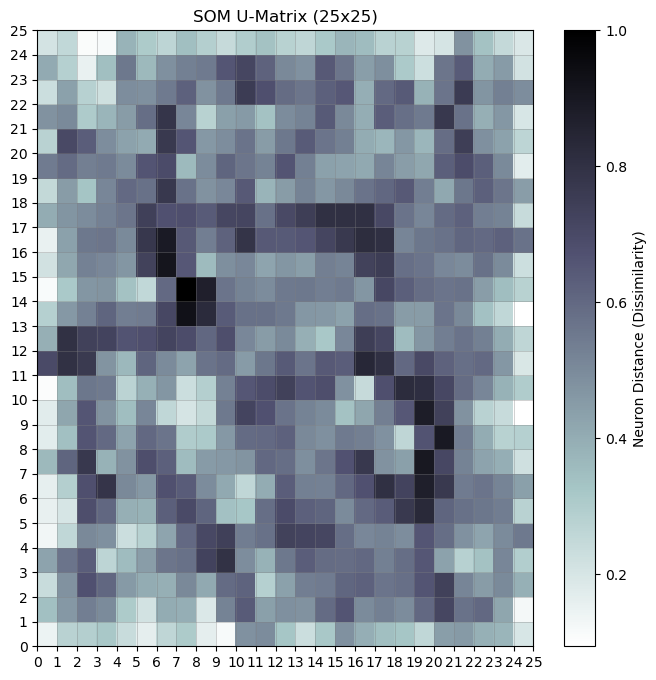

In [78]:
# --- U-Matrix Visualization ---

def plot_som_topology(som, grid_size):
    """
    Plots the Unified Distance Matrix (U-Matrix).
    Darker colors = Clusters (valleys).
    Lighter colors = Boundaries (ridges).
    """
    plt.figure(figsize=(8, 8))
    
    # 1. Get the U-Matrix (distance to neighbors)
    u_matrix = som.distance_map().T
    
    # 2. Plot heatmap
    plt.pcolor(u_matrix, cmap='bone_r') 
    plt.colorbar(label='Neuron Distance (Dissimilarity)')
    
    # Add grid lines
    plt.xticks(np.arange(grid_size[0] + 1))
    plt.yticks(np.arange(grid_size[1] + 1))
    plt.grid(color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    
    plt.title(f'SOM U-Matrix ({grid_size[0]}x{grid_size[1]})')
    plt.show()

# --- EXECUTION ---
plot_som_topology(som_model, som_grid)

The U-Matrix visualization reveals clear regions of low and high inter-neuron distances, corresponding respectively to dense areas of similar observations and boundaries between distinct groups.

The presence of multiple well-defined valleys separated by lighter ridges indicates a coherent topological organization of the demographic data. Although transitions between regions are smooth, which is expected in demographic segmentation, the map confirms the existence of meaningful underlying structure.

These patterns are consistent with the clustering results obtained using K-Means and Gaussian Mixture Models, supporting the robustness and interpretability of the final segmentation.

In [65]:
# --- Two-Stage Clustering (SOM + K-Means) ---

# 1. Extract Weights (The "Prototypes")
# Reshape to (Num_Neurons, Num_Features)
weights = som_model.get_weights().reshape(-1, df_demographic.shape[1])

# 2. Find Best K for the Weights (Mini-Optimization)
print("Optimizing K-Means for SOM weights...")
best_k = 0
best_sil = -1
for k in range(3, 21): # Test small range suitable for map size
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(weights)
    sil = silhouette_score(weights, labels)
    print(f"K={k} -> Silhouette: {sil:.3f}")
    if sil > best_sil:
        best_sil = sil
        best_k = k

print(f"\nSelected K={best_k} for SOM Two-Stage Clustering.")

# 3. Final Clustering on Weights
km_som = KMeans(n_clusters=best_k, n_init=10, random_state=42)
neuron_clusters = km_som.fit_predict(weights)

# 4. Map Clusters back to Original Customers
# Strategy: Customer -> Best Matching Unit (Neuron) -> Neuron's Cluster
print("Mapping clusters back to customers...")
som_labels = []
X_data = df_demographic.values

for x in X_data:
    w = som_model.winner(x)
    # Flatten 2D coordinate (x,y) to 1D index
    idx = w[0] * som_grid[1] + w[1]
    som_labels.append(neuron_clusters[idx])

# 5. Save to DataFrame
df_demographic_evaluation['cluster_som'] = som_labels
print(f"Done. 'cluster_som' added with {best_k} clusters.")

Optimizing K-Means for SOM weights...
K=3 -> Silhouette: 0.172


c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K=4 -> Silhouette: 0.170
K=5 -> Silhouette: 0.169


c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K=6 -> Silhouette: 0.175
K=7 -> Silhouette: 0.173


...

K=19 -> Silhouette: 0.236


c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


K=20 -> Silhouette: 0.243

Selected K=20 for SOM Two-Stage Clustering.
Mapping clusters back to customers...


c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Done. 'cluster_som' added with 20 clusters.


In [ ]:
# --- Two-Stage Clustering (SOM + K-Means) ---

# 1. Extract Weights
weights = som_model.get_weights().reshape(-1, df_demographic.shape[1])

# 1B. Identify which neurons are actually used (BMU hits)
X_data = df_demographic.values
hits = np.zeros(weights.shape[0], dtype=int)

for x in X_data:
    w = som_model.winner(x)
    idx = w[0] * som_grid[1] + w[1]
    hits[idx] += 1

used_idx = np.where(hits > 0)[0]
weights_used = weights[used_idx]

print(f"Total neurons: {weights.shape[0]} | Used neurons (hits>0): {len(used_idx)}")

# 2. Find Best K for the Weights (Mini-Optimization)
print("Optimizing K-Means for SOM weights...")
best_k = 0
best_sil = -1

# Don't test k larger than used neurons - 1
max_k = min(20, len(weights_used) - 1)

for k in range(3, max_k + 1):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(weights_used)
    sil = silhouette_score(weights_used, labels)
    print(f"K={k} -> Silhouette: {sil:.3f}")
    if sil > best_sil:
        best_sil = sil
        best_k = k

print(f"\nSelected K={best_k} for SOM Two-Stage Clustering.")

# 3. Final Clustering on Used Weights
km_som = KMeans(n_clusters=best_k, n_init=10, random_state=42)
used_neuron_clusters = km_som.fit_predict(weights_used)

# Build a full neuron_clusters array
neuron_clusters = np.full(weights.shape[0], -1, dtype=int)
neuron_clusters[used_idx] = used_neuron_clusters

# 4. Map Clusters back to Original Customers
print("Mapping clusters back to customers...")
som_labels = []

for x in X_data:
    w = som_model.winner(x)
    idx = w[0] * som_grid[1] + w[1]
    som_labels.append(neuron_clusters[idx])

# 5. Save to DataFrame
df_demographic_evaluation['cluster_som'] = som_labels
print(f"Done. 'cluster_som' added with {best_k} clusters.")

Total neurons: 625 | Used neurons (hits>0): 347
Optimizing K-Means for SOM weights...
K=3 -> Silhouette: 0.170


c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K=4 -> Silhouette: 0.165
K=5 -> Silhouette: 0.170


c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K=6 -> Silhouette: 0.178
K=7 -> Silhouette: 0.176


...

K=19 -> Silhouette: 0.238


c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K=20 -> Silhouette: 0.243

Selected K=20 for SOM Two-Stage Clustering.


c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Mapping clusters back to customers...
Done. 'cluster_som' added with 20 clusters.


For K=5

In [ ]:
# --- Two-Stage Clustering (SOM + K-Means) with Fixed K=5 ---

# 1. Extract Weights (The "Prototypes")
weights = som_model.get_weights().reshape(-1, df_demographic.shape[1])

# 2. Identify which neurons are actually used (BMU hits)
X_data = df_demographic.values
hits = np.zeros(weights.shape[0], dtype=int)

for x in X_data:
    w = som_model.winner(x)
    idx = w[0] * som_grid[1] + w[1] 
    hits[idx] += 1

used_idx = np.where(hits > 0)[0]
weights_used = weights[used_idx]

print(f"Total neurons: {weights.shape[0]} | Used neurons (hits>0): {len(used_idx)}")

# 3. Fixed K for interpretability and consistency
fixed_k = 5
print(f"Clustering SOM weights with fixed K={fixed_k}...")

km_som = KMeans(n_clusters=fixed_k, n_init=10, random_state=42)
used_neuron_clusters = km_som.fit_predict(weights_used)

# Build a full neuron_clusters array
neuron_clusters = np.full(weights.shape[0], -1, dtype=int)
neuron_clusters[used_idx] = used_neuron_clusters

# Optional quick quality check (silhouette on used neurons)
sil_fixed = silhouette_score(weights_used, used_neuron_clusters)
print(f"Silhouette (SOM prototypes, K={fixed_k}): {sil_fixed:.3f}")

# 4. Map Clusters back to Original Customers
print("Mapping clusters back to customers...")
som_labels = []

for x in X_data:
    w = som_model.winner(x)
    idx = w[0] * som_grid[1] + w[1]
    som_labels.append(neuron_clusters[idx])

# 5. Save to DataFrame
df_demographic_evaluation['cluster_som'] = som_labels
print(f"Done. 'cluster_som' added with {fixed_k} clusters.")


Total neurons: 625 | Used neurons (hits>0): 347
Clustering SOM weights with fixed K=5...
Silhouette (SOM prototypes, K=5): 0.170
Mapping clusters back to customers...


c:\Users\Duarte\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Done. 'cluster_som' added with 5 clusters.


A two-stage clustering approach was applied by first training a Self-Organizing Map (SOM) to learn a low-dimensional representation of the demographic data. The neuron weight vectors (prototypes) were then clustered using K-Means in order to identify higher-level groupings in the SOM topology.

In an initial exploratory step, the number of clusters was allowed to vary. As expected, silhouette scores increased with higher values of K, reflecting increasingly fine-grained partitions of the SOM prototypes. However, this behavior primarily favored fragmentation and did not lead to interpretable or actionable demographic segments.

Consequently, the number of clusters was fixed at K = 5 to ensure consistency with the K-Means and Gaussian Mixture Model results, as well as to preserve interpretability. This final configuration provides a balanced segmentation that captures the main demographic structure while avoiding over-segmentation

## 3.4 Clustering Evaluation and Comparison

In [81]:
# ...existing code...
print("\nFinal Clustering Evaluation Summary:")

# 1. Prepare Data for Calculation
X = df_demographic.values
sst = np.sum((X - X.mean(axis=0)) ** 2)  # Total Sum of Squares

# 2. Define Methods and their Column Names
clustering_methods = {
    'K-Means++': 'cluster_kmeans',
    'Mean Shift': 'cluster_meanshift',
    'DBSCAN': 'cluster_dbscan',
    'GMM': 'cluster_gmm',
    'SOM (Two-Stage)': 'cluster_som'
}

results_list = []

# 3. Loop through each method and calculate metrics
for method_name, col_name in clustering_methods.items():
    if col_name in df_demographic_evaluation.columns:
        labels = df_demographic_evaluation[col_name].values
        unique_labels = np.unique(labels)
        
        # --- A. Basic Counts ---
        has_noise = -1 in labels
        n_clusters = len(unique_labels) - (1 if has_noise else 0)
        noise_pct = (np.sum(labels == -1) / len(labels)) * 100 if has_noise else 0.0
        
        # --- B. Silhouette & Davies-Bouldin ---
        if n_clusters > 1:
            if has_noise:
                mask = labels != -1
                if np.sum(mask) > 1 and len(np.unique(labels[mask])) > 1:
                    sil = silhouette_score(X[mask], labels[mask])
                    db = davies_bouldin_score(X[mask], labels[mask])
                else:
                    sil, db = np.nan, np.nan
            else:
                sil = silhouette_score(X, labels)
                db = davies_bouldin_score(X, labels)
        else:
            sil, db = np.nan, np.nan
            
        # --- C. R2 Score ---
        ssw = 0
        for k in unique_labels:
            cluster_data = X[labels == k]
            ssw += np.sum((cluster_data - cluster_data.mean(axis=0)) ** 2)
        r2 = 1 - (ssw / sst)

        # --- D. Specific Metrics (New Section) ---
        specific_metric = "-"
        try:
            if method_name == 'K-Means++':
                specific_metric = f"Inertia: {kmeans_final.inertia_:.0f}"
            elif method_name == 'Mean Shift':
                specific_metric = f"Bandwidth: {final_bandwidth:.3f}"
            elif method_name == 'DBSCAN':
                specific_metric = f"Eps: {selected_eps}, MinPts: {selected_min_samples}"
            elif method_name == 'GMM':
                bic = gmm_final.bic(X)
                avg_unc = df_demographic_evaluation['gmm_uncertainty'].mean()
                specific_metric = f"BIC: {bic:.0f} | Avg Unc: {avg_unc:.3f}"
            elif method_name == 'SOM (Two-Stage)':
                qe = som_model.quantization_error(X)
                te = som_model.topographic_error(X)
                specific_metric = f"QE: {qe:.3f} | TE: {te:.3f}"
        except NameError:
            specific_metric = "Model not in memory"

        # Append results
        results_list.append({
            'Method': method_name,
            'Clusters': n_clusters,
            'Silhouette': round(sil, 4),
            'Davies-Bouldin': round(db, 4),
            'R2 Score': round(r2, 4),
            'Noise (%)': round(noise_pct, 2),
            'Specific Metric': specific_metric
        })

# 4. Create and Display DataFrame
df_eval_summary = pd.DataFrame(results_list).set_index('Method')

# Sort by Silhouette Score for better comparison
df_eval_summary = df_eval_summary.sort_values('Silhouette', ascending=False)

print("Comparison of all Clustering Methods:")
display(df_eval_summary.style.background_gradient(cmap='YlGn', subset=['Silhouette']).background_gradient(cmap='RdYlGn_r', subset=['Davies-Bouldin']).background_gradient(cmap='YlGn', subset=['R2 Score']))


Final Clustering Evaluation Summary:
Comparison of all Clustering Methods:


,Clusters,Silhouette,Davies-Bouldin,R2 Score,Noise (%),Specific Metric
Method,,,,,,
K-Means++,5,0.184900,2.002800,0.367200,0.000000,Inertia: 21699
SOM (Two-Stage),5,0.159400,2.058500,0.360600,0.000000,QE: 0.334 | TE: 0.030
GMM,5,0.143200,2.629700,0.285200,0.000000,BIC: -1077605 | Avg Unc: 0.000
Mean Shift,8,0.119900,2.050500,0.311500,0.000000,Bandwidth: 1.204
DBSCAN,27,0.116800,1.261700,0.461000,14.470000,"Eps: 1.0, MinPts: 30"


The comparative evaluation of all clustering methods highlights clear trade-offs between cluster quality, model complexity, and interpretability. K-Means++ achieved the highest Silhouette score while maintaining a strong R² value and producing a compact solution with five well-balanced clusters and no noise points.

Although alternative approaches such as DBSCAN and Mean Shift captured additional variance or finer-grained structures, they resulted in a higher number of clusters or significant noise, reducing interpretability and practical applicability. Gaussian Mixture Models and the two-stage SOM approach provided stable and coherent segmentations but did not outperform K-Means in terms of overall separation quality.

Considering the balance between cluster validity, stability, and interpretability, K-Means++ with five clusters was selected as the final model for demographic segmentation.